# 04 — Venue EDA
Ground stats, avg scores, chasing success, boundary rates

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['figure.facecolor'] = '#16213e'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#444'
ACCENT = '#f5a623'
PALETTE = ['#f5a623','#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c','#e67e22','#e91e63','#00bcd4','#ff5722']

matches = pd.read_csv('../data/processed/matches_clean.csv')
deliveries = pd.read_csv('../data/processed/deliveries_clean.csv')

# Normalize venue names (duplicates like 'Wankhede Stadium' and 'Wankhede Stadium, Mumbai')
venue_map = {
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'Delhi Daredevils': 'Arun Jaitley Stadium',
    'Punjab Cricket Association Stadium, Mohali': 'PCA Stadium Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'PCA Stadium Mohali',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi Intl Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
}
matches['venue'] = matches['venue'].replace(venue_map)
deliveries = deliveries.merge(matches[['id','venue']], left_on='match_id', right_on='id', how='left')
print('Venues:', matches['venue'].nunique())

Venues: 53


## 1. Most Matches Hosted — Top 15 Venues

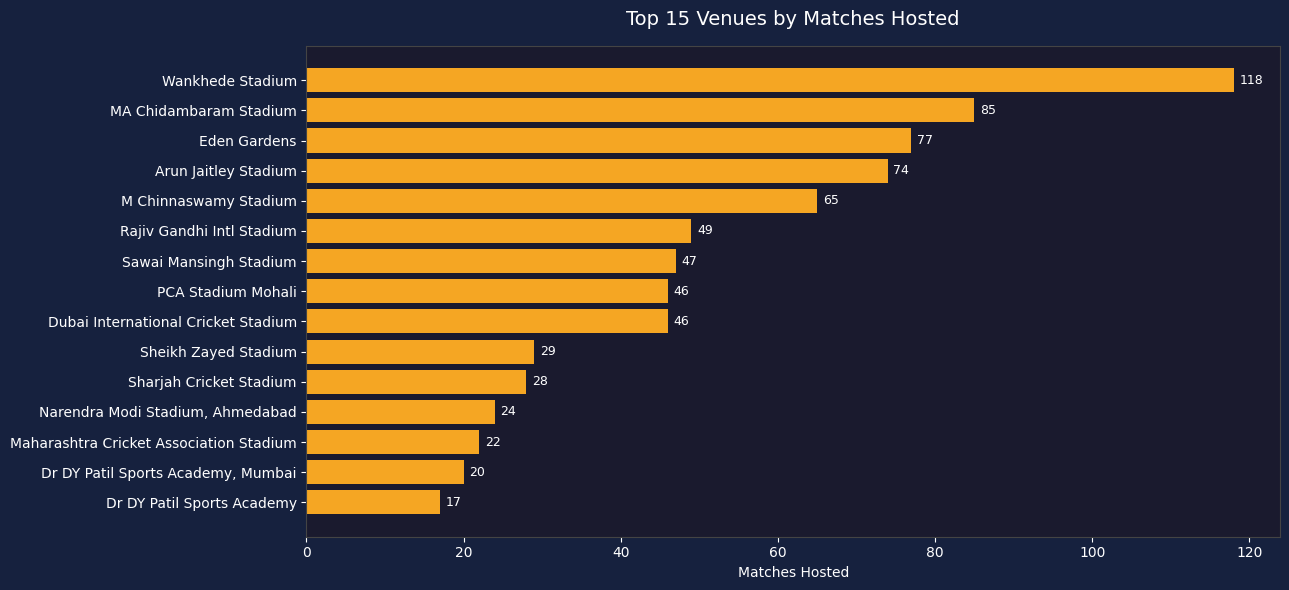

In [2]:
venue_matches = matches['venue'].value_counts().head(15).reset_index()
venue_matches.columns = ['venue', 'matches']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(venue_matches['venue'], venue_matches['matches'], color=ACCENT, edgecolor='none')
ax.bar_label(bars, padding=4, color='white', fontsize=9)
ax.set_title('Top 15 Venues by Matches Hosted', fontsize=14, pad=15)
ax.set_xlabel('Matches Hosted')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/13_venue_matches.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Average First Innings Score — Top 12 Venues

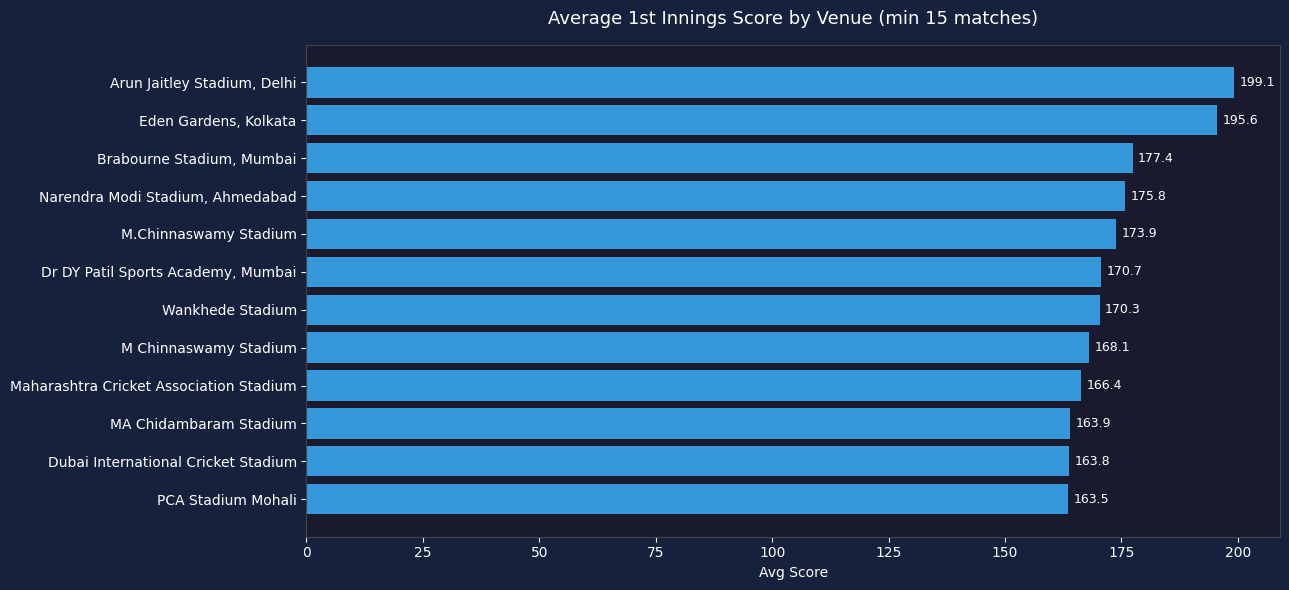

                                  venue  avg_score  matches  max_score
            Arun Jaitley Stadium, Delhi      199.1       16        266
                  Eden Gardens, Kolkata      195.6       16        261
              Brabourne Stadium, Mumbai      177.4       17        217
       Narendra Modi Stadium, Ahmedabad      175.8       24        233
                  M.Chinnaswamy Stadium      173.9       15        218
     Dr DY Patil Sports Academy, Mumbai      170.7       20        216
                       Wankhede Stadium      170.3      118        235
                  M Chinnaswamy Stadium      168.1       65        263
Maharashtra Cricket Association Stadium      166.4       22        211
                 MA Chidambaram Stadium      163.9       85        246
    Dubai International Cricket Stadium      163.8       46        219
                     PCA Stadium Mohali      163.5       46        240


In [3]:
inning1 = deliveries[deliveries['inning'] == 1].groupby(['match_id','venue'])['total_runs'].sum().reset_index()
inning1.columns = ['match_id', 'venue', 'first_innings_score']

venue_scores = inning1.groupby('venue').agg(
    avg_score=('first_innings_score', 'mean'),
    matches=('match_id', 'count'),
    max_score=('first_innings_score', 'max'),
    min_score=('first_innings_score', 'min')
).reset_index()
venue_scores['avg_score'] = venue_scores['avg_score'].round(1)

# Min 15 matches
top_venues = venue_scores[venue_scores['matches'] >= 15].sort_values('avg_score', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_venues['venue'], top_venues['avg_score'], color='#3498db', edgecolor='none')
ax.bar_label(bars, fmt='%.1f', padding=4, color='white', fontsize=9)
ax.set_title('Average 1st Innings Score by Venue (min 15 matches)', fontsize=13, pad=15)
ax.set_xlabel('Avg Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/14_avg_first_innings.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_venues[['venue','avg_score','matches','max_score']].to_string(index=False))

## 3. Chase Success Rate by Venue

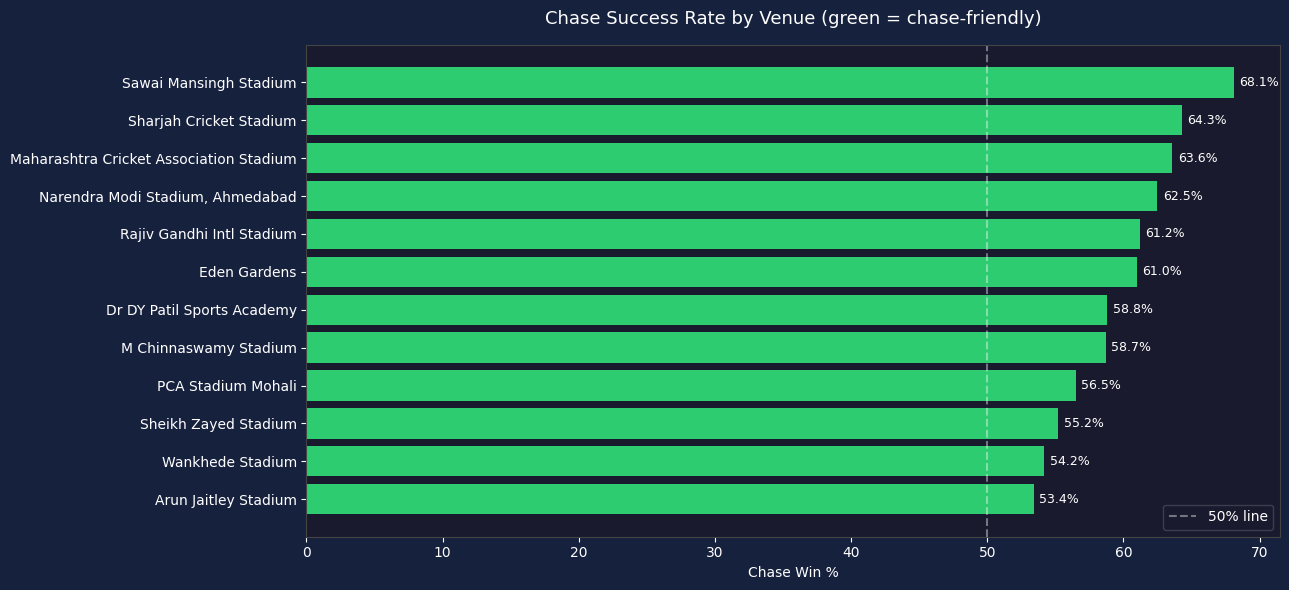

In [4]:
valid = matches[matches['winner'] != 'No Result'].copy()

# Who batted first?
valid['bat_first'] = valid.apply(
    lambda r: r['team1'] if (r['toss_winner'] == r['team2'] and r['toss_decision'] == 'field')
    else (r['team2'] if (r['toss_winner'] == r['team1'] and r['toss_decision'] == 'field')
    else (r['team1'] if (r['toss_decision'] == 'bat' and r['toss_winner'] == r['team1'])
    else r['team2'])), axis=1
)
valid['chasing_won'] = valid['bat_first'] != valid['winner']

chase_by_venue = valid.groupby('venue').agg(
    total=('chasing_won', 'count'),
    chase_wins=('chasing_won', 'sum')
).reset_index()
chase_by_venue['chase_pct'] = (chase_by_venue['chase_wins'] / chase_by_venue['total'] * 100).round(1)
chase_top = chase_by_venue[chase_by_venue['total'] >= 15].sort_values('chase_pct', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#2ecc71' if x >= 50 else '#e74c3c' for x in chase_top['chase_pct']]
bars = ax.barh(chase_top['venue'], chase_top['chase_pct'], color=colors, edgecolor='none')
ax.bar_label(bars, fmt='%.1f%%', padding=4, color='white', fontsize=9)
ax.axvline(50, color='white', linestyle='--', alpha=0.4, label='50% line')
ax.set_title('Chase Success Rate by Venue (green = chase-friendly)', fontsize=13, pad=15)
ax.set_xlabel('Chase Win %')
ax.legend(framealpha=0.2)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/15_chase_success.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Boundary Rate by Venue — Batsman vs Bowler Grounds

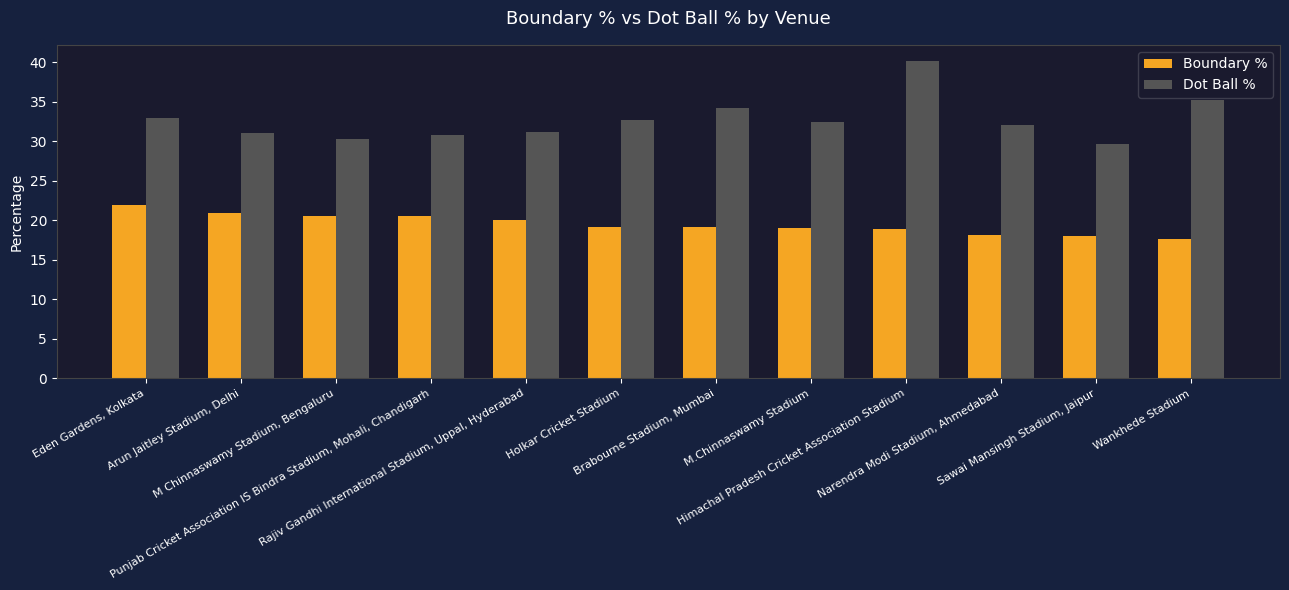

In [5]:
venue_del = deliveries[deliveries['inning'].isin([1, 2])].copy()
boundary_venue = venue_del.groupby('venue').agg(
    balls=('ball', 'count'),
    fours=('is_four', 'sum'),
    sixes=('is_six', 'sum'),
    dots=('is_dot', 'sum')
).reset_index()
boundary_venue['boundary_pct'] = ((boundary_venue['fours'] + boundary_venue['sixes']) / boundary_venue['balls'] * 100).round(1)
boundary_venue['dot_pct'] = (boundary_venue['dots'] / boundary_venue['balls'] * 100).round(1)
boundary_venue['six_pct'] = (boundary_venue['sixes'] / boundary_venue['balls'] * 100).round(1)

top_boundary = boundary_venue[boundary_venue['balls'] >= 1000].sort_values('boundary_pct', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(top_boundary))
w = 0.35
ax.bar([i - w/2 for i in x], top_boundary['boundary_pct'], width=w, label='Boundary %', color=ACCENT, edgecolor='none')
ax.bar([i + w/2 for i in x], top_boundary['dot_pct'], width=w, label='Dot Ball %', color='#555', edgecolor='none')
ax.set_xticks(list(x))
ax.set_xticklabels(top_boundary['venue'], rotation=30, ha='right', fontsize=8)
ax.set_title('Boundary % vs Dot Ball % by Venue', fontsize=13, pad=15)
ax.set_ylabel('Percentage')
ax.legend(framealpha=0.2)
plt.tight_layout()
plt.savefig('../assets/16_boundary_venue.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Export Venue Stats for Power BI

In [6]:
venue_export = venue_scores.merge(chase_by_venue[['venue','chase_pct']], on='venue', how='left')
venue_export = venue_export.merge(boundary_venue[['venue','boundary_pct','dot_pct','six_pct']], on='venue', how='left')
venue_export.to_csv('../data/processed/venue_stats.csv', index=False)
print('Saved venue_stats.csv')
print(venue_export.head())

Saved venue_stats.csv
                                               venue  avg_score  matches  \
0                               Arun Jaitley Stadium      162.9       74   
1                        Arun Jaitley Stadium, Delhi      199.1       16   
2                                   Barabati Stadium      167.7        7   
3                Barsapara Cricket Stadium, Guwahati      180.0        3   
4  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...      165.4       14   

   max_score  min_score  chase_pct  boundary_pct  dot_pct  six_pct  
0        231         56       53.4          16.5     34.1      4.8  
1        266        127       43.8          20.9     31.0      7.5  
2        231        126       42.9          16.7     32.9      4.0  
3        199        144       33.3          18.0     33.3      4.3  
4        235        121       46.2          15.2     34.6      4.9  
